# Análise Exploratória dos Dados (EDA)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import DADOS_ORIGINAIS, DADOS_TRATADOS

sns.set_theme(palette="bright")

 Importando todas as bibliotecas necessarias para a Análise exploratoria

# Conhecendo a base de dados

In [2]:
df = pd.read_csv(DADOS_ORIGINAIS)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
with pd.option_context("display.max_columns", 35):
    display(df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

Identifiquei que todas as colunas numericas sao do tipo inteira. Isso pode indicar que os dados sofreram algum tratamento prévio para arredondar todos os valores

In [5]:
with pd.option_context("float_format", "{:.2f}".format, "display.max_columns", 35):
    display(df.describe())

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.00,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.00,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.00,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.00,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.00,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.00,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.00,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.00,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.00,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.00,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.00,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.00,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [6]:
df.describe(exclude="number")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [7]:
df.nunique()[df.nunique() == 1]

EmployeeCount    1
Over18           1
StandardHours    1
dtype: int64

 Identificando colunas com apenas um valor para assim exclui-la, pois com 1 valor apenas não é possivel fazer uma analise

In [8]:
df = df.drop(columns=df.nunique()[df.nunique() == 1].index)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

In [9]:
df["Attrition"].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

 Realizo essa verificação para identificar base de dados desbalanceada

Como pode ser visto, temos um desbalanceamento, com 83% dos dados estando em "Não", caso o tratamento na seja feito o treinamento do modelo de machine learning pode apresentar queda no desempenho

In [10]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

Verificação de valores nulos e duplicados, a base não apresenta nenhum dos dois

In [12]:
df["EmployeeNumber"].nunique()

1470

identifiquei que a coluna "EmployeeNumber" contem apenas valores unicos, vou remove-la pois a mesma tambem nao auxilia na análise exploratoria   

In [13]:
df = df.drop(["EmployeeNumber"], axis = 1)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [14]:
colunas_categoricas_nao_ordenadas = [
    "BusinessTravel",
    "Department",
    "EducationField",
    "Gender",
    "JobRole",
    "MaritalStatus",
    "OverTime",
]

colunas_categoricas_ordenadas = [
    "Education",
    "EnvironmentSatisfaction",
    "JobSatisfaction",
    "JobInvolvement",
    "JobLevel",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "WorkLifeBalance",
]

coluna_alvo = ["Attrition"]

colunas_numericas = [
    coluna for coluna in df.columns if coluna not in (
        colunas_categoricas_nao_ordenadas + colunas_categoricas_ordenadas + coluna_alvo
    )
]

 Dividindo as colunas entre não ordenadas, ordenadas e coluna alvo. Realizo a divisão aqui pois assim ja preparo cada coluna para ser usada depois na etapa de machine learning previamente, como ja estou analisando qual o valor de cada coluna, acredito ser otimizado ja separá-las de acordo com suas peculiaridades

# Análise Grafica

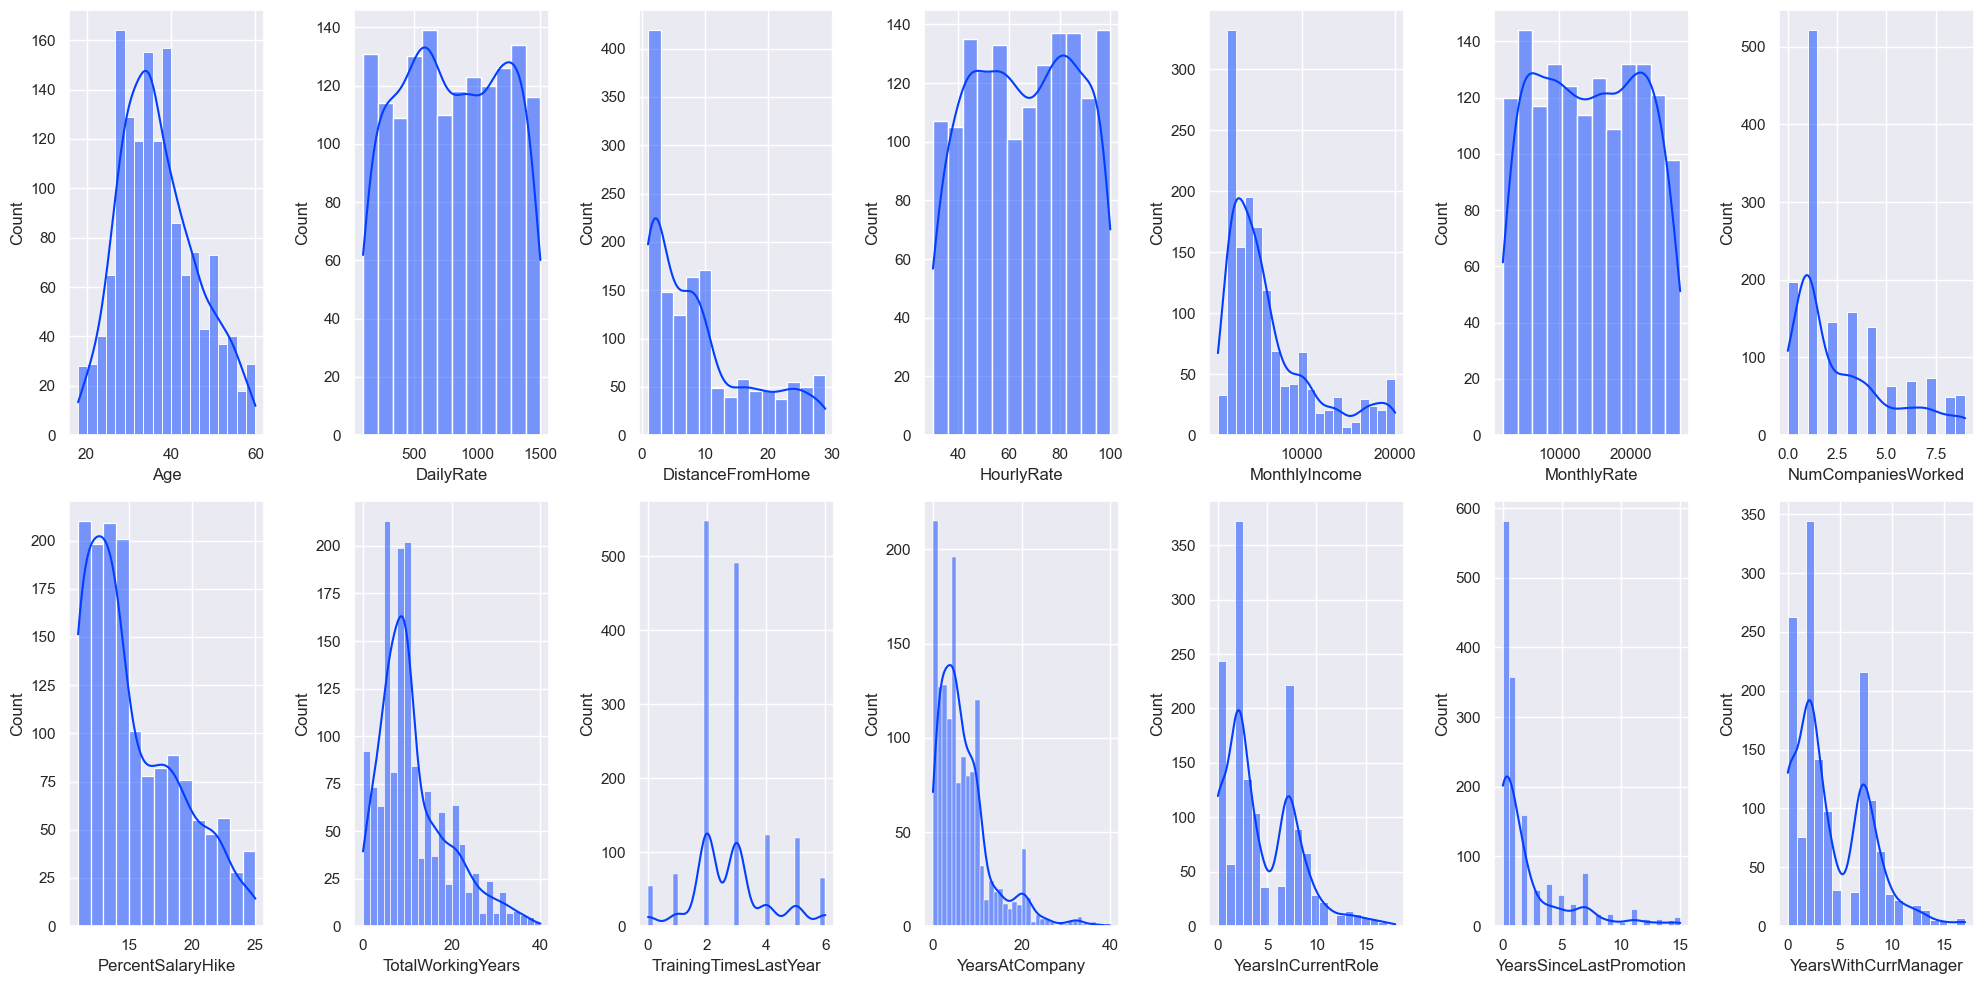

In [15]:
fig, axs = plt.subplots (2, 7, figsize=(20, 10))

for ax, coluna in zip(axs.flatten(), colunas_numericas):
    sns.histplot(data=df, x=coluna, ax=ax, kde=True)

plt.tight_layout()

#  O que os gráficos nos dizem sobre os funcionários?

Como muitos desses gráficos não seguem uma "distribuição normal" (ou seja, não têm aquele formato perfeito de sino onde a maioria fica no meio), aqui está o que conseguimos descobrir de forma simples sobre o perfil da empresa:

- Age (Idade): A maioria dos nossos colaboradores está na faixa dos 30 aos 40 anos. Temos poucos funcionários muito jovens (abaixo de 20) ou mais maduros (acima de 55).
- DailyRate / HourlyRate / MonthlyRate (Valores/Taxas de Trabalho): Esses gráficos são bem planos. Isso nos mostra que a distribuição desses valores e taxas é praticamente uniforme dentro da empresa.
- DistanceFromHome (Distância de Casa): A grande maioria das pessoas mora muito perto da empresa (menos de 10 km). Conforme a distância aumenta, o número de funcionários cai drasticamente.
- MonthlyIncome (Renda Mensal): O gráfico despenca da esquerda para a direita. Isso é o comportamento padrão de quase toda empresa: a maioria dos funcionários ganha salários menores, e poucos recebem os salários mais altos de diretoria/gerência.
- NumCompaniesWorked (Número de Empresas onde Já Trabalhou): A maior parte do nosso DataFrame trabalhou em apenas uma ou duas empresas antes de vir para essa empresa. Temos pouquíssimos profissionais que "pularam" por muitas empresas (7 ou mais).
- PercentSalaryHike (Percentual de Aumento Salarial): A maioria dos aumentos concedidos fica concentrada na faixa mais baixa (entre 11% e 14%). Aumentos maiores são  mais raros.
- TotalWorkingYears (Tempo Total de Carreira): Nosso quadro é composto majoritariamente por profissionais com menos de 10 anos de experiência total.
- TrainingTimesLastYear (Treinamentos no Ano Passado): O padrão da empresa é oferecer 2 ou 3 treinamentos por ano para os funcionários. Raramente alguém fica sem nenhum ou recebe mais do que 4.
- YearsAtCompany (Anos na Empresa): Há uma concentração gigante de pessoas novas de casa (com até 5 anos de empresa). Pouquíssimos colaboradores têm uma jornada de longo prazo (mais de 15 ou 20 anos) aqui dentro.
- YearsInCurrentRole (Anos na Função Atual): A maioria das pessoas está há pouco tempo na função atual (0 a 3 anos). Isso indica que as pessoas mudam de cargo com frequência ou há muitas contratações novas.
- YearsSinceLastPromotion (Anos Desde a Última Promoção): A barra mais alta está no zero, o que significa que a maioria das pessoas foi promovida recentemente (há menos de um ano) ou acabou de entrar no cargo atual. No entanto, existe uma parcela pequena de pessoas que está há mais de 5 ou 10 anos estagnada.
- YearsWithCurrManager (Anos com o Mesmo Gestor): A maior parte dos funcionários está com o gestor atual há pouco tempo (menos de 2 anos), o que pode indicar rotatividade de liderança ou reestruturações frequentes nas equipes.




In [16]:

estatisticas_dist = pd.DataFrame({
    'Assimetria (Skewness)': df[colunas_numericas].skew(),
    'Curtose (Kurtosis)': df[colunas_numericas].kurt()
})

estatisticas_dist

,Assimetria (Skewness),Curtose (Kurtosis)
Age,0.413286,-0.404145
DailyRate,-0.003519,-1.203823
DistanceFromHome,0.958118,-0.224833
HourlyRate,-0.032311,-1.196398
MonthlyIncome,1.369817,1.005233
MonthlyRate,0.018578,-1.214956
NumCompaniesWorked,1.026471,0.010214
PercentSalaryHike,0.821128,-0.300598
TotalWorkingYears,1.117172,0.918270
TrainingTimesLastYear,0.553124,0.494993


com este histograma identificamos que muito dos dados nao seguem uma distribuição normal, para demonstrar isso de forma clara utilizei os metodos de assimetria e curtose.


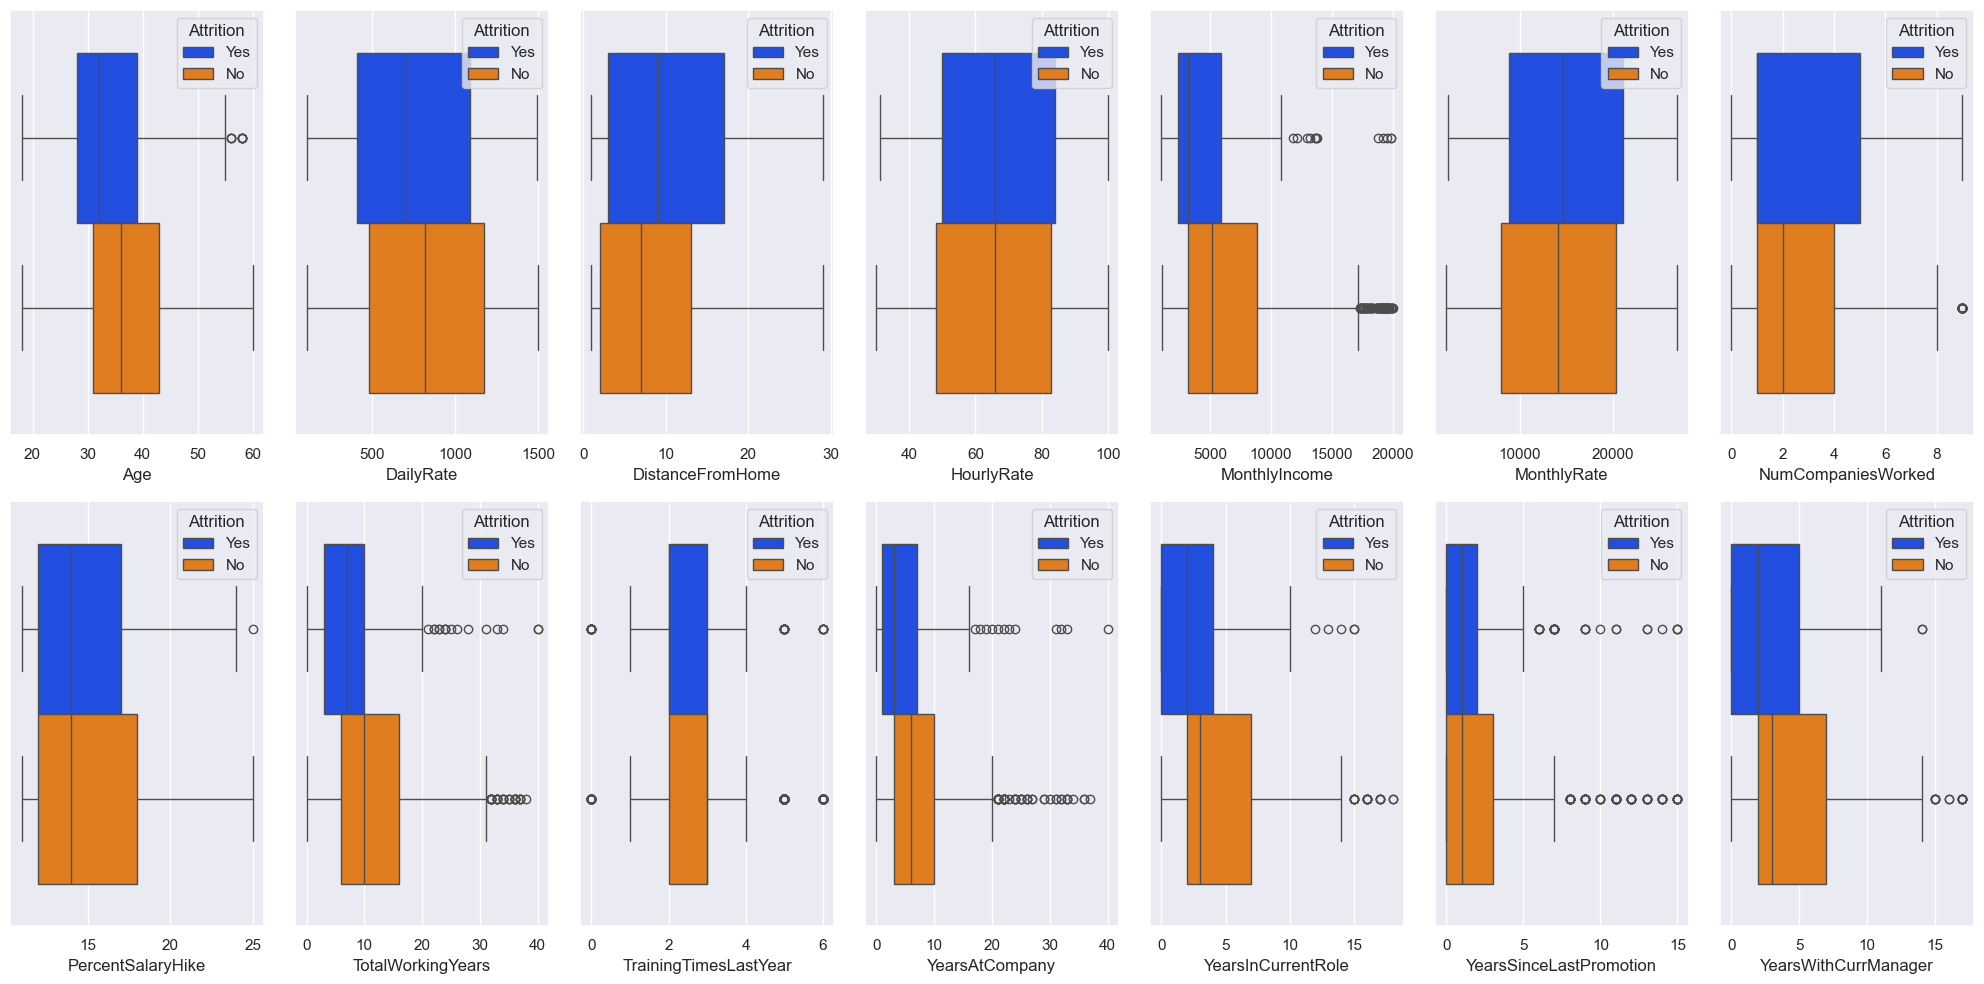

In [17]:
fig, axs = plt.subplots (2, 7, figsize=(20, 10))

for ax, coluna in zip(axs.flatten(), colunas_numericas):
    sns.boxplot(data=df, x=coluna, ax=ax, hue= "Attrition" )

plt.tight_layout()

O Grafico Boxplot é uma ferramenta visual que consegue resumir, em uma única imagem, como um grupo de dados está distribuído e onde está concentrado os maiores valores do seu do dataframe. Diferente do grafico criado acima (histplot), o boxplot divide o dado em 4 partes contendo 25% dos dados em cada uma.

Sendo elas:

- A Caixa Central (O "Retângulo"): Representa os 50% do meio do seu público. É onde está a grande massa de funcionários da empresa. Se a caixa for muito comprida, significa que os dados são muito variados; se for achatada, significa que a maioria das pessoas tem valores muito parecidos.

- A Linha Cortando a Caixa: É a Mediana (o meio exato da fila). Metade dos funcionários está abaixo dessa linha e a outra metade está acima.

- As Linhas Laterais (As "Antenas"): Mostram os limites onde os valores ainda são considerados comuns ou normais para aquela realidade. Elas vão até o valor mínimo e máximo aceitáveis na distribuição.

- Os Pontinhos Soltos (Exceções ou Outliers): São pessoas que estão completamente fora do padrão do resto do grupo. Por exemplo, em um gráfico de salários, os pontinhos lá na frente representam os poucos diretores que ganham muito acima da média da empresa.





### Por que temos duas cores (Azul e Laranja)?

Nesta análise, nós dividimos os funcionários em dois grupos para comparar o comportamento deles lado a lado:

- Azul (Yes): Funcionários que saíram da empresa (Attrition).

- Laranja (No): Funcionários que continuam na empresa.

Se a caixa azul estiver muito "descolada" ou desalinhada em relação à caixa laranja, significa que aquela característica influencia na decisão de sair da empresa. Se as duas caixas estiverem perfeitamente alinhadas, significa que aquela variável afeta quem sai e quem fica exatamente da mesma forma, não sendo um fator decisivo.

Dito isso para mim, o boxplot que me chamou a atenção foi o "DistanceFromHome", ele indica um claro indício que influência na decisão de sair da empresa


<Axes: >

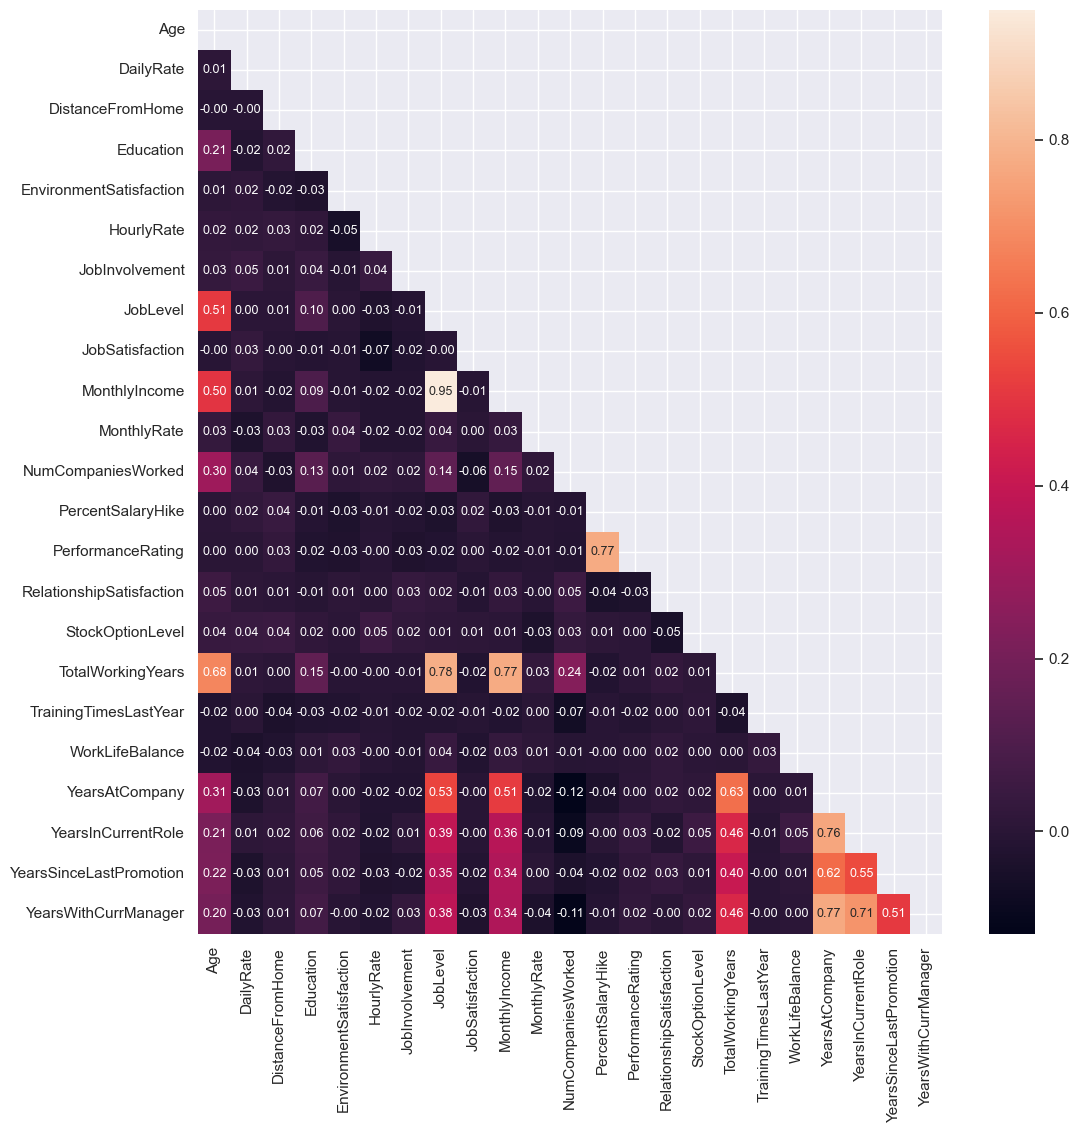

In [18]:
corr = df.select_dtypes("number").corr()

matriz = np.triu(corr)

fig, ax = plt.subplots(figsize=(12,12))

sns.heatmap(
    corr,
    mask=matriz,
    annot=True,
    fmt=".2f",
    ax=ax,
    annot_kws={"fontsize":9}
)
    

## O que é um heatmap ? (Mapa de Correlação)

Este gráfico funciona como um cruzamento de ruas. Ele pega duas informações quaisquer da nossa empresa e mede o nível de afinidade entre elas. O resultado é um número que vai de -1 a 1:

- A Cor Clara/Laranja (Correlação Forte): Quanto mais próximo de 1 (cores mais claras e vivas), maior é a afinidade. Significa que quando uma coisa aumenta, a outra obrigatoriamente aumenta junto.
   - Exemplo prático gráfico: Olhe o cruzamento entre MonthlyIncome (Renda Mensal) e JobLevel (Nível do Cargo). O número é 0.95. Isso nos diz: quem tem um nível de cargo maior, ganha mais. Eles caminham quase juntos.
 
-  A Cor Escura/Preta (Sem Correlação): Quanto mais próximo de 0 (cores bem escuras), significa que as duas coisas não têm relação nenhuma. O que acontece com uma não afeta em nada a outra.
    -  Exemplo prático no seu gráfico: O cruzamento entre DistanceFromHome (Distância de Casa) e MonthlyIncome (Renda Mensal) é -0.02 (praticamente zero). Isso mostra que morar perto ou longe do trabalho não tem nada a ver com o quanto a pessoa ganha.
 
-  Valores Negativos (Inversamente Proporcionais): Se houvesse números muito negativos (perto de -1), significaria que quando uma coisa aumenta, a outra diminui.

### variaveis com relações fortes:

- Anos na Empresa (YearsAtCompany) vs. Anos com o Mesmo Gestor (YearsWithCurrManager): A correlação é de 0.77. Isso mostra que os funcionários tendem a ficar estagnados sob a mesma liderança conforme passam os anos na empresa, ou que a liderança é muito estável.
  
- Anos na Empresa (YearsAtCompany) vs. Anos na Função Atual (YearsInCurrentRole): Com 0.76 de correlação, indica que boa parte do tempo de casa do funcionário é passado realizando a mesma exata função, o que pode sugerir falta de mobilidade interna.

- Tempo Total de Carreira (TotalWorkingYears) vs. Nível do Cargo (JobLevel) e Renda Mensal (MonthlyIncome): Correlações de 0.78 e 0.77. Mostra de forma clara que o tempo de mercado dita diretamente a senioridade do cargo e o salário na empresa.

- Avaliação de Desempenho (PerformanceRating) vs. Percentual de Aumento Salarial (PercentSalaryHike): A correlação aqui é de 0.77.
    - O insight de negócio: Isso prova que a empresa possui uma política de reconhecimento financeira muito meritocrática e direta. Quem tem notas de performance mais altas recebe, quase que obrigatoriamente, os maiores percentuais de aumento salarial. 
      
- Nível do Cargo (JobLevel) vs. Renda Mensal (MonthlyIncome): A correlação é quase perfeita (0.95). Quanto maior o cargo na hierarquia, maior o salário.

- dade (Age) vs. Tempo Total de Carreira (TotalWorkingYears): Correlação de 0.68. Naturalmente, funcionários mais velhos acumulam mais anos totais de trabalho na carreira.

### Baixa Correlação

- Distância de Casa (DistanceFromHome) vs. Equilíbrio entre Vida e Trabalho (WorkLifeBalance): Correlação muito proxima a zero, indicando que a distância da casa ate a empresa não impacta na decisão de saida do funcionário

- MonthlyRate vs. PercentSalaryHike : Correlação proxima a zero, logo pode indicar que o salário que a empresa fornece esta competitivo com o mercado




C:\Users\CHG\AppData\Local\Temp\ipykernel_28736\3186319323.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
C:\Users\CHG\AppData\Local\Temp\ipykernel_28736\3186319323.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
C:\Users\CHG\AppData\Local\Temp\ipykernel_28736\3186319323.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
C:\Users\CHG\AppData\Local\Temp\ipykernel_28736\3186319323.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usi

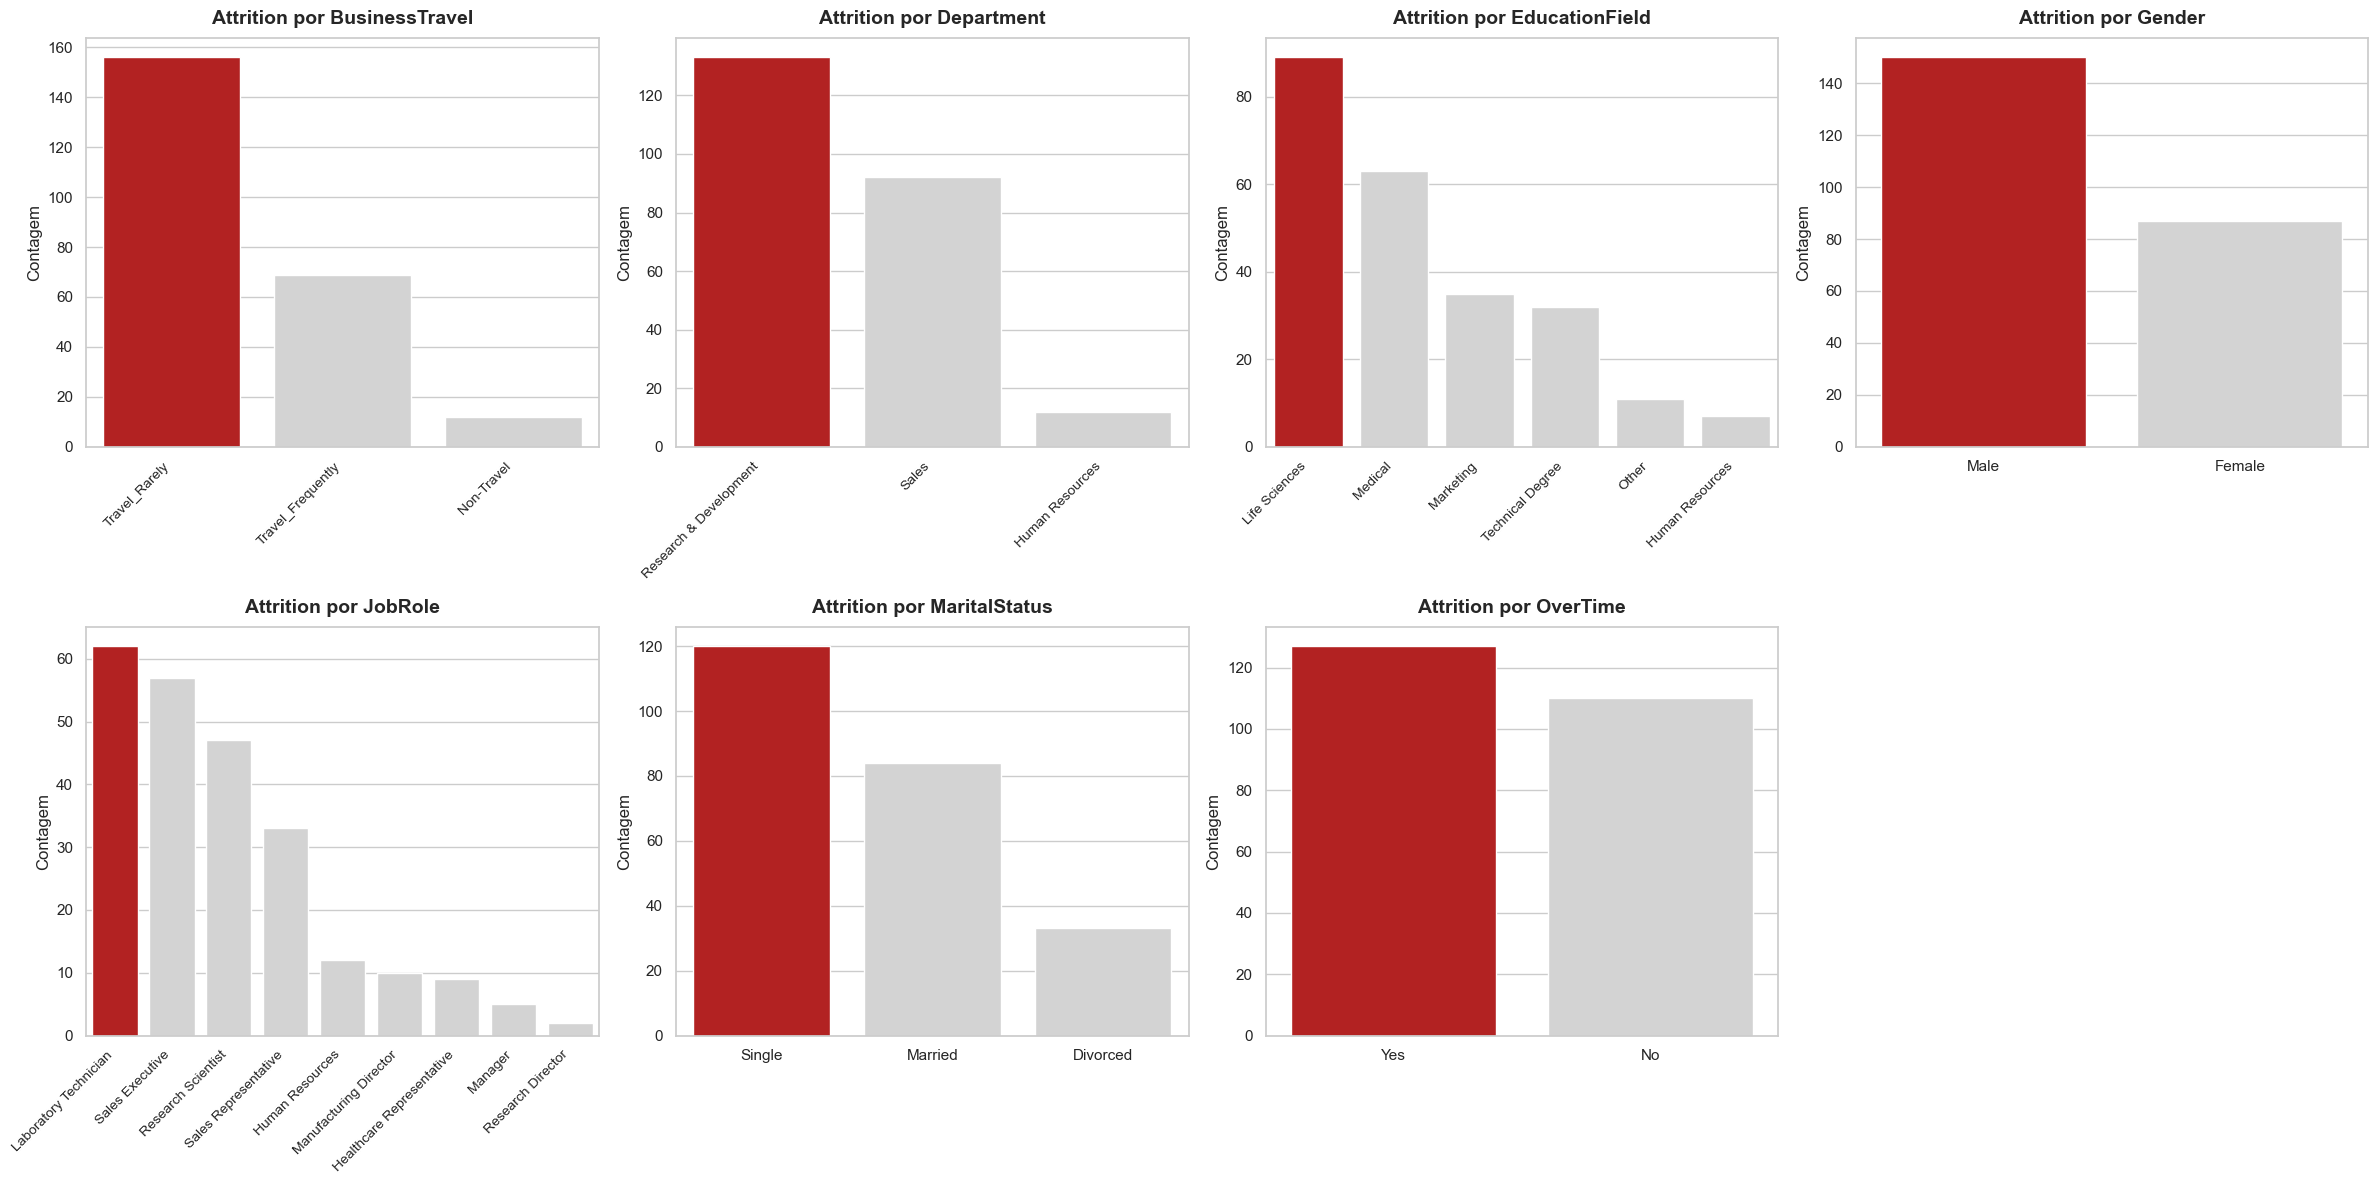

In [77]:
# Configura um estilo mais limpo e profissional
sns.set_theme(style="whitegrid")

# Ajustamos o tamanho para manter uma boa proporção
fig, axs = plt.subplots(2, 4, figsize=(24, 12))
axs_flat = axs.flatten()

for i, coluna in enumerate(colunas_categoricas_nao_ordenadas):
    ax = axs_flat[i]
    
    # Filtrando os dados diretamente
    dados_filtrados = df[df["Attrition"] == "Yes"]
    
    ordem_maior_para_menor = dados_filtrados[coluna].value_counts().index
    
    # Usando countplot
    sns.countplot(
        data=dados_filtrados,
        x=coluna,
        order=ordem_maior_para_menor,
        legend=False,
        ax=ax
    )

   # Deixa apenas a primeira barra vermelha
    for j, barra in enumerate(ax.patches):
        if j == 0:
            barra.set_facecolor("#B22222")
        else:
            barra.set_facecolor("#D3D3D3")
            

    # Ajustes de títulos e eixos
    ax.set_title(f"Attrition por {coluna}", fontsize=14, pad=10, fontweight='bold')
    ax.set_xlabel("") 
    ax.set_ylabel("Contagem", fontsize=12)
    
    # Rotaciona o texto se a categoria tiver muitos itens ou nomes longos
    if dados_filtrados[coluna].nunique() > 3 or dados_filtrados[coluna].astype(str).str.len().max() > 10:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)

# Esconde o oitavo gráfico (vazio) para não quebrar o layout
fig.delaxes(axs_flat[-1])

# Ajusta o espaçamento para os textos rotacionados não cortarem
plt.tight_layout()
plt.show()

## Principais insights encontrados
- Os desligamentos concentram-se principalmente em colaboradores que viajam raramente.
- O departamento de Research & Development apresentou o maior número de desligamentos.
- A formação em Life Sciences foi a mais frequente entre os colaboradores desligados.
- Homens representaram a maior parte dos desligamentos observados.
- Os cargos de Laboratory Technician e Sales Executive apresentaram maior número de desligamentos.
- Colaboradores solteiros foram os que mais deixaram a empresa.
- Funcionários que realizavam horas extras (OverTime = Yes) apresentaram maior ocorrência de desligamentos

# Otimização do DataFrame

 Após a análise realizada, irei preparar a otimização dos meus dados para a proxima etapa que será a criação de um modelo de machine learning para prever a probabilidade de algum funcionário solicitar o desligamento. As análises feita acima tem como objetivo de entender em como estão distribuidos os dados do dataframe e suas features basicas, para que eu tenha uma ideia de como posso prosseguir com análise e se realmente as features destacadas são o que aumentam a chance do funcionário se desligar

In [26]:
colunas_valores_inteiros = [coluna for coluna in df.select_dtypes("int")]

colunas_valores_inteiros

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [27]:
df[colunas_valores_inteiros] = df[colunas_valores_inteiros].apply(
    pd.to_numeric, downcast="integer"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int8  
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int16 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int8  
 6   Education                 1470 non-null   int8  
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int8  
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int8  
 11  JobInvolvement            1470 non-null   int8  
 12  JobLevel                  1470 non-null   int8  
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

### destacar que mesmo sendo pequena  a base de dados, futuramente a empresa poderia ter um aumento massivo de dados e com isso a otimização se tornaria mais efetiva que agora, porem demonstrar esse conhecimento desde ja

In [28]:
df.to_parquet(DADOS_TRATADOS, index=False)

Parar o EDA aqui, ir para machine learning, ao identificar as features mais importantes podemos retorar aqui para fazer crosstab, estatistica e afins para direcionar para onde eu quero a análise.